In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM

In [2]:
o = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSbs')
ost = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSt')
tf = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TFlight')
tc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TContact')
e = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Elevation')
pw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Power')
pc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Pace')
rsi = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='RSI')
wpx = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPX')
wpy = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPY')
sw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='StepWidth')
nj = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='NJ')
d = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Distance')
tt = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TTotal')
tp = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TPoints')

In [3]:
#swap
tt.loc[:40, 'Test'] = 'final'
tt.loc[40:, 'Test'] = 'initial'

In [4]:
df_list = [tf, tc, e, pw, pc, rsi, wpx, wpy, sw, nj, d, tp]
melt_df_list = []
for df in df_list:
    df.loc[:,'Test'] = tt.loc[:,'Test']    #swap
    melt_df_list = melt_df_list + [pd.melt(df, id_vars=['Name','Test','Group','Sex','NJumps', 'Mean'], 
                                   value_vars=range(1,170), var_name='Jump', value_name='val')]

In [5]:
melt_df_list_timed = []
for df in melt_df_list:
    melt_df_timed = df.copy()
    melt_df_timed['time'] = melt_df_list[11].val
    melt_df_list_timed = melt_df_list_timed + [melt_df_timed]

In [6]:
values = ['Flight Time (s)', 'Contact Time (s)', 'Elevation (cm)', 'Propulsive Power (W/Kg)', 'Pace (jumps/s)', 'RSI (m/s)', 'StepWidth (mm)',
'Distance (cm)']
keys = [0, 1, 2, 3, 4, 5, 8, 10]
dict = {k: v for k, v in zip(keys, values)}
dict

{0: 'Flight Time (s)',
 1: 'Contact Time (s)',
 2: 'Elevation (cm)',
 3: 'Propulsive Power (W/Kg)',
 4: 'Pace (jumps/s)',
 5: 'RSI (m/s)',
 8: 'StepWidth (mm)',
 10: 'Distance (cm)'}

In [7]:
# valori = ['timp in aer (s)', 'timp contact (s)', 'inaltime (cm)', 'putere (W/Kg)',
#           'viteza (sarituri/s)', 'IFR (m/s)', 'distanta picioare (mm)', 'distanta deviere (cm)']
# chei = [0, 1, 2, 3, 4, 5, 8, 10]
# dict2 = {k: v for k, v in zip(chei, valori)}
# dict2

Text(20.249999999999993, 0.5, 'Flight Time (s)')

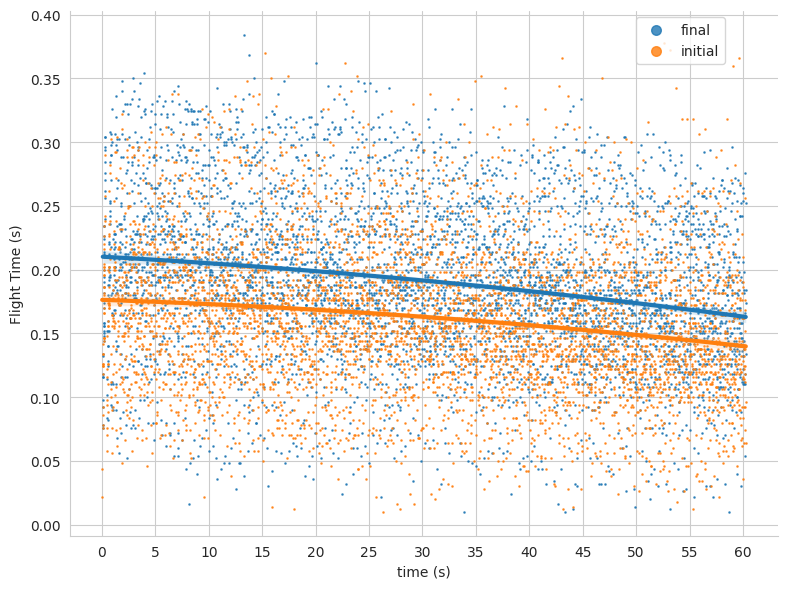

In [8]:
i=0
sns.set_style("whitegrid")
sns.lmplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<0.4],
           x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

Text(0, 0.5, 'Flight Time (s)')

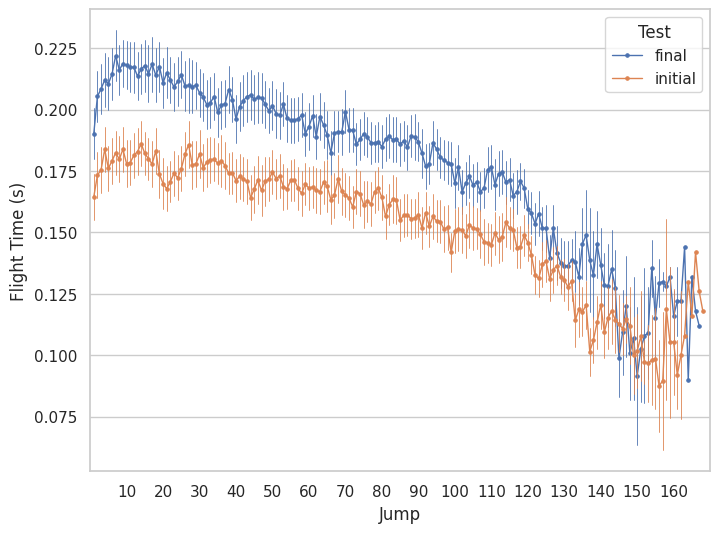

In [9]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
i=0
sns.set(rc={"figure.figsize":(8,6)})
sns.set_style("whitegrid")
sns.pointplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<0.4],
              x='Jump', y='val', hue='Test',
              estimator='mean', errorbar='se', legend=True, lw = 1,
              err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
# plt.xticks(ticks=[], labels=[])
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' mean.svg')

In [10]:
# i=2
# sns.set_style("whitegrid")
# sns.lmplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<20],
#            x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
#            scatter_kws={"s": 0.75}, line_kws={"lw": 3},
#            height=6, aspect=1.33).set(xticks=range(0, 65, 5))
# plt.legend(loc=[0.8,0.9], markerscale=8)
# plt.xlabel('timp (s)')
# plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - regresie.svg')
# plt.savefig('putere - regresie.svg')
# plt.savefig('viteza - regresie.svg')
# plt.savefig('IFR - regresie.svg')

In [11]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
# i=2
# sns.set(rc={"figure.figsize":(8,6)})
# sns.set_style("whitegrid")
# sns.pointplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<20],
#               x='Jump', y='val', hue='Test',
#               estimator='mean', errorbar='se', legend=True, lw = 1,
#               err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
# plt.xlabel('saritura')
# # plt.xticks(ticks=[], labels=[])
# plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - medie.svg')
# plt.savefig('putere - medie.svg')
# plt.savefig('viteza - medie.svg')
# plt.savefig('IFR - medie.svg')

##### Merging a dataframe containing weight and height, normalising parameters for weight, height, bmi

In [12]:
wh = o.loc[:,['Name', 'Weight1', 'Height2']].copy()
wh.columns = ['Name', 'weight', 'height']

In [14]:
n = []
for df in melt_df_list_timed:
    ndf = df.copy()
    ndf = ndf.merge(wh, how='left', on ='Name')
    ndf.loc[:, 'bmi'] = 10000 * ndf.loc[:, 'weight'] / (ndf.loc[:, 'height']**2)
    ndf['nw'] = ndf.val.div(ndf.weight)
    ndf['nh'] = ndf.val.div(ndf.height)
    ndf['nbmi'] = ndf.val.div(ndf.bmi)
    n = n + [ndf]

Text(36.0, 0.5, 'Flight Time (s)')

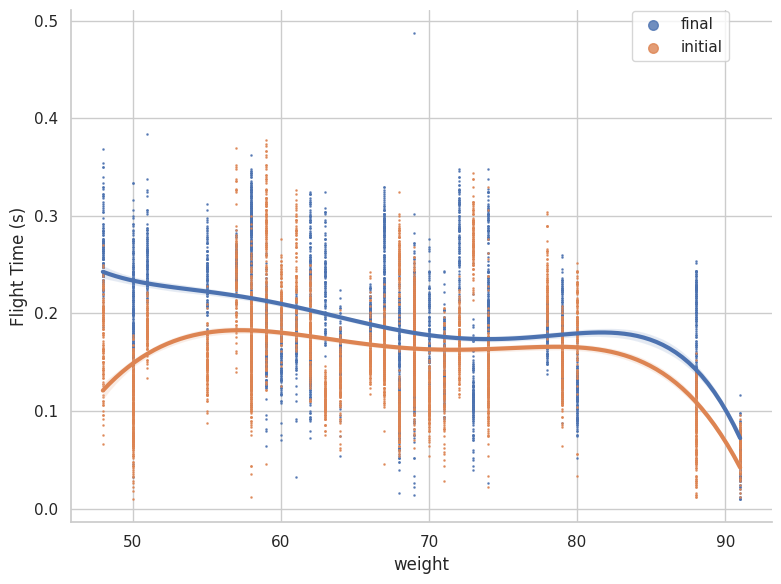

In [18]:
i=0
sns.set_style("whitegrid")
sns.lmplot(n[i],
           x='weight', y='val', hue='Test', order = 5, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33)
# .set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
# plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

##### Anova

In [19]:
n[2].loc[n[2].val.isna()].groupby('Test').Jump.min()
# minimum Jump in each test phase that contains no data

Test
final      105
initial    115
Name: Jump, dtype: object

In [ ]:
AnovaRM(data=n[2].loc[n[2].Jump<105], depvar='val', subject='Name', within=['Test','Jump']).fit().summary()
# cannot handle missing values

,F Value,Num DF,Den DF,Pr > F
Test,6.1358,1.0000,39.0000,0.0177
Jump,11.3422,103.0000,4017.0000,0.0000
Test:Jump,1.5427,103.0000,4017.0000,0.0004


##### Regression with Jumps

In [20]:
model = smf.ols('val ~ Test * Jump', data = n[2])

In [21]:
print('TSS:    ', model.fit().centered_tss, '\nSSR:    ', model.fit().ssr, '\nESS:    ', model.fit().ess,
      '\n\nTest:   ', model.fit().centered_tss - smf.ols('val ~ Test', data=n[2]).fit().ssr,
      '\nJump:   ', model.fit().centered_tss - smf.ols('val ~ Jump', data=n[2]).fit().ssr,
      '\nTxJ:    ', model.fit().ess - smf.ols('val ~ Test + Jump', data=n[2]).fit().ess, sep='')

TSS:    84052.92563310919
SSR:    71533.91223809721
ESS:    12519.013395011978

Test:   4260.362348896553
Jump:   8041.539644442135
TxJ:    579.0071421790199


In [ ]:
sum((model.endog - model.endog.mean())**2)
# TSS, Total sum of squares = SST in ANOVA

np.float64(84052.92563310693)

In [ ]:
model.fit().resid.T @ model.fit().resid
# the same thing as: sum((model.fit().resid)**2)
# SSR, Sum of squared residuals = SSE in ANOVA

np.float64(71533.91223809721)

In [44]:
sum((model.fit().fittedvalues - model.endog.mean())**2)
# ESS, Explained sum of squares, sum of main effects + interaction in ANOVA

12519.013395012009

In [22]:
-model.fit().ssr / model.fit().centered_tss + 1
# R^2, coeff of determination

np.float64(0.1489420302828891)

In [23]:
model.fit().summary().tables[0]
# too many terms due to Jumps being categorical

Dep. Variable:,val,R-squared:,0.149
Model:,OLS,Adj. R-squared:,0.121
Method:,Least Squares,F-statistic:,5.357
Date:,"Sat, 06 Sep 2025",Prob (F-statistic):,3.96e-177
Time:,20:36:11,Log-Likelihood:,-25083.
No. Observations:,10559,AIC:,5.084e+04
Df Residuals:,10224,BIC:,5.327e+04
Df Model:,334,,
Covariance Type:,nonrobust,,


#### Regression with time

In [24]:
model_timed = smf.ols('val ~ time * Test', data=n[2])

In [25]:
print('TSS:    ', model_timed.fit().centered_tss, '\nSSR:    ', model.fit().ssr, '\nESS:    ', model.fit().ess,
      '\n\nTest:   ', model_timed.fit().centered_tss - smf.ols('val ~ Test', data=n[2]).fit().ssr,
      '\nJump:   ', model_timed.fit().centered_tss - smf.ols('val ~ time', data=n[2]).fit().ssr,
      '\nTxJ:    ', model_timed.fit().ess - smf.ols('val ~ Test + time', data=n[2]).fit().ess, sep='')

TSS:    84052.92563310919
SSR:    71533.91223809721
ESS:    12519.013395011978

Test:   4260.362348896553
Jump:   3159.3087177167763
TxJ:    180.86365564048174


In [26]:
model_timed.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     353.0
Date:                Sat, 06 Sep 2025   Prob (F-statistic):          1.74e-218
Time:                        20:36:45   Log-Likelihood:                -25430.
No. Observations:               10559   AIC:                         5.087e+04
Df Residuals:                   10555   BIC:                         5.090e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.0703      0.075     80.513      0.000       5.922       6.218
Test[T.initial]         -1.7374      0.105    -16.484      0.000      -1.944      -1.531
time                    -0.0395      0.002    -18.368      0.000      -0.044      -0.035
time:Test[T.initial]     0.0151      0.003      4.999      0.000       0.009       0.021
==============================================================================
Omnibus:                     2002.812   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4057.587
Skew:                           1.135   Prob(JB):                         0.00
Kurtosis:                       5.018   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
pd.DataFrame(model_timed.exog)
# using '*' in the ols formula introduces the interaction term in the last column, a product of columns 1 and 2

,0,1,2,3
0,1.0,0.0,0.262,0.000
1,1.0,0.0,0.226,0.000
2,1.0,0.0,0.294,0.000
3,1.0,0.0,0.304,0.000
4,1.0,0.0,0.304,0.000
...,...,...,...,...
10554,1.0,0.0,59.724,0.000
10555,1.0,1.0,59.418,59.418
10556,1.0,0.0,60.080,0.000
10557,1.0,1.0,59.790,59.790


In [ ]:
np.linalg.inv(model_timed.exog.T @ model_timed.exog) @ model_timed.exog.T @ model_timed.endog
# (X.T @ X)^-1 @ X.T @ Y

array([ 6.07026422, -1.73742964, -0.0395169 ,  0.01509195])

In [ ]:
np.linalg.pinv(model_timed.exog) @ model_timed.endog
# pinv(X) @ Y

array([ 6.07026422, -1.73742964, -0.0395169 ,  0.01509195])

##### MSE, Mean squared error
##### RMSE, Root mean squared error = SEE, Standard error of the estimate

In [ ]:
model_timed.nobs - model_timed.df_resid
# nobs does not have the nan values, df_resid = nobs - 4 (because of 4 coefficients, including intercept)
# this is ddof, delta dof

np.float64(4.0)

In [32]:
model_timed.fit().ssr/(model_timed.nobs - 4)

np.float64(7.237163776632443)

In [ ]:
model_timed.fit().resid.var(ddof = 4)
# Variance very close to SSR/df_resid because the residual mean and sum are always 0
# Variance is the sum of squares of (Ri - Rm)

np.float64(7.2371637766324435)

In [33]:
model_timed.fit().mse_resid

np.float64(7.237163776632443)

In [35]:
model_timed.fit().scale

np.float64(7.237163776632443)

In [ ]:
model_timed.fit().mse_resid**0.5
# RMSE, Root mean squared error

np.float64(2.6901977207321477)

##### Covariance and correlation
###### https://www.geeksforgeeks.org/engineering-mathematics/mathematics-covariance-and-correlation/ 
###### Covariance (population) = 1/n * sum( (Xi-Xm) * (Yi-Ym) )
###### If X = Y covariance becomes variance
###### Correlation = Covariance / (stdX * stdY)
###### If X = Y, correlation = 1

In [ ]:
model_timed.fit().cov_params() # this is not an usual covariance matrix

,Intercept,Test[T.initial],time,time:Test[T.initial]
Intercept,0.005684,-0.005684,-0.000141,0.000141
Test[T.initial],-0.005684,0.011110,0.000141,-0.000276
time,-0.000141,0.000141,0.000005,-0.000005
time:Test[T.initial],0.000141,-0.000276,-0.000005,0.000009


In [ ]:
pd.DataFrame(np.linalg.inv(model_timed.exog.T @ model_timed.exog) * model_timed.fit().mse_resid)
# this is the only way to calculate it

,0,1,2,3
0,0.005684,-0.005684,-0.000141,0.000141
1,-0.005684,0.011110,0.000141,-0.000276
2,-0.000141,0.000141,0.000005,-0.000005
3,0.000141,-0.000276,-0.000005,0.000009


In [ ]:
model_timed.fit().cov_params()**0.5
# standard errors of coefficients are the square roots of the diagonal terms, which are variances

,Intercept,Test[T.initial],time,time:Test[T.initial]
Intercept,0.075395,NaN,NaN,0.011871
Test[T.initial],NaN,0.105403,0.011871,NaN
time,NaN,0.011871,0.002151,NaN
time:Test[T.initial],0.011871,NaN,NaN,0.003019


In [45]:
model_timed.fit().bse

Intercept               0.075395
Test[T.initial]         0.105403
time                    0.002151
time:Test[T.initial]    0.003019
dtype: float64

In [130]:
model_timed.fit(cov_type='HC0').bse

Intercept               0.089351
Test[T.initial]         0.114170
time                    0.002325
time:Test[T.initial]    0.003043
dtype: float64

###### One sample t-test is (sample mean - hyp. pop. mean) / (std / n^0.5)
###### Hyp. pop. mean = 0, meaning H0 states that coeff = 0 (no contribution)
###### std/n^0.5 = standard error, sample mean = coefficient value
###### T statistic = coefficient / coefficient standard error

In [126]:
model_timed.fit().params/model_timed.fit().bse

Intercept               80.512775
Test[T.initial]        -16.483685
time                   -18.368239
time:Test[T.initial]     4.999096
dtype: float64

In [132]:
model_timed.fit().get_prediction().summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,6.059911,0.074906,5.913081,6.206740,0.784572,11.335250
1,6.061333,0.074973,5.914372,6.208295,0.785991,11.336676
2,6.058646,0.074846,5.911934,6.205359,0.783310,11.333982
3,6.058251,0.074828,5.911575,6.204927,0.782916,11.333586
4,6.058251,0.074828,5.911575,6.204927,0.782916,11.333586
...,...,...,...,...,...,...
13207,3.710157,0.073217,3.566638,3.853675,-1.565091,8.985405
13246,2.881553,0.072055,2.740312,3.022794,-2.393634,8.156739
13287,3.696089,0.073877,3.551277,3.840901,-1.579194,8.971372
13326,2.872467,0.072734,2.729895,3.015039,-2.402755,8.147689


In [139]:
cip = n[2].merge(model_timed.fit().get_prediction().summary_frame(), how = 'left', left_index=True, right_index=True).copy()

In [169]:
cip.columns

Index(['Name', 'Test', 'Group', 'Sex', 'NJumps', 'Mean', 'Jump', 'val', 'time',
       'weight', 'height', 'bmi', 'nw', 'nh', 'nbmi', 'mean', 'mean_se',
       'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper'],
      dtype='object')

<Axes: xlabel='Jump', ylabel='val'>

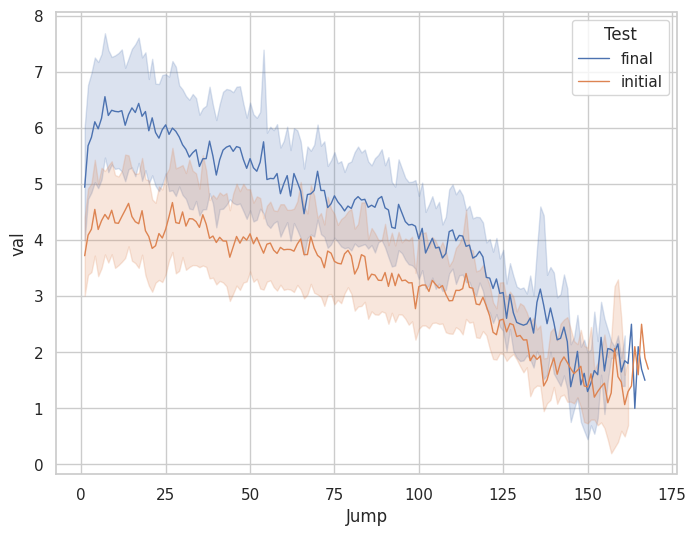

In [185]:
sns.lineplot(cip, x='Jump', y='val', hue='Test', lw=1,
             estimator='mean')

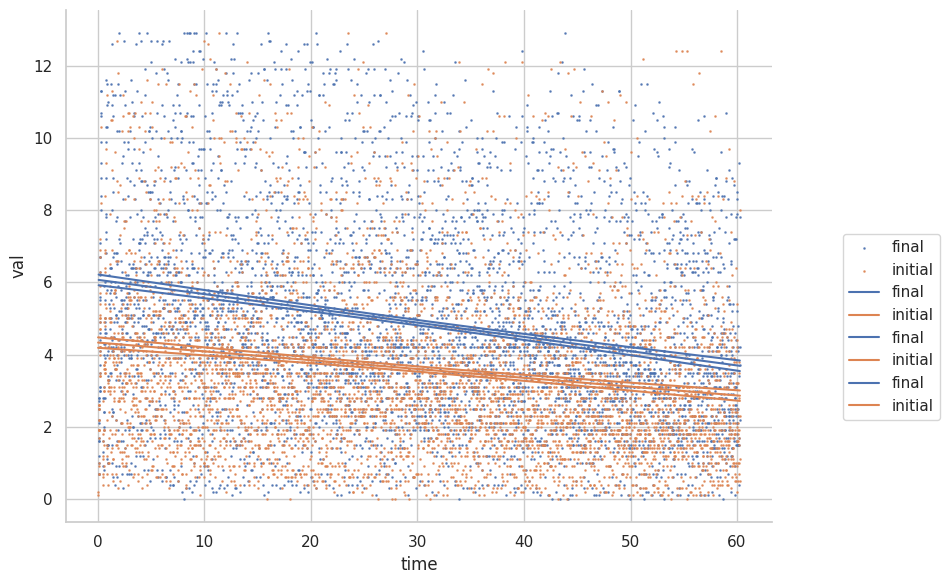

In [184]:
sns.lmplot(cip.loc[cip.val<13],
           x='time', y='val', hue='Test', order = 5, x_ci='sd', legend=False, fit_reg=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33)
sns.lineplot(cip, x='time', y='mean', hue='Test')
sns.lineplot(cip, x='time', y='mean_ci_lower', hue='Test')
sns.lineplot(cip, x='time', y='mean_ci_upper', hue='Test')
# sns.lineplot(cip, x='time', y='obs_ci_lower', hue='Test')
# sns.lineplot(cip, x='time', y='obs_ci_upper', hue='Test')
plt.legend(loc=[1.1,0.2])
plt.show()

In [128]:
model_timed.fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,6.0703,0.075,80.513,0.000,5.922,6.218
Test[T.initial],-1.7374,0.105,-16.484,0.000,-1.944,-1.531
time,-0.0395,0.002,-18.368,0.000,-0.044,-0.035
time:Test[T.initial],0.0151,0.003,4.999,0.000,0.009,0.021


#### Checking the contributions of more parameters

In [27]:
smf.ols('val ~ time + weight + Test + Group', data = n[2]).fit(cov_type='HC0').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     688.4
Date:                Sat, 06 Sep 2025   Prob (F-statistic):               0.00
Time:                        00:55:54   Log-Likelihood:                -24754.
No. Observations:               10559   AIC:                         4.952e+04
Df Residuals:                   10554   BIC:                         4.955e+04
Df Model:                           4                                         
Covariance Type:                  HC0                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.1181      0.167     60.473      0.000       9.790      10.446
Test[T.initial]    -1.3232      0.049    -26.905      0.000      -1.420      -1.227
Group[T.J]          0.9442      0.052     18.057      0.000       0.842       1.047
time               -0.0320      0.001    -22.649      0.000      -0.035      -0.029
weight             -0.0692      0.002    -31.200      0.000      -0.074      -0.065
==============================================================================
Omnibus:                     2147.430   Durbin-Watson:                   2.039
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4651.253
Skew:                           1.180   Prob(JB):                         0.00
Kurtosis:                       5.238   Cond. No.                         547.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC0)
"""